In [11]:
"""
Market Basket Analysis (MBA) on Real-World Retail Transaction Data
--------------------------------------------------------------------
This script performs association rule mining on retail transaction
data to discover which products are frequently purchased together.

Steps:
1. Load and clean transaction data
2. Build shopping baskets per transaction
3. Identify frequent items and item pairs (support-based filtering)
4. Generate association rules (support, confidence, lift)
5. Visualize top-selling products
"""

import itertools
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
DATA_PATH = "transaction_data.csv"
MIN_SUPPORT = 0.01                 # minimum support threshold for an item/pair to be "frequent"
MAX_ITEMS_FOR_PAIR_MINING = 80      # cap on number of items considered for pairwise mining (for performance)

In [17]:
# ---------------------------------------------------------------
# Step 1: Load raw data
# ---------------------------------------------------------------
raw_df= pd.read_csv("transaction_data.csv")
raw_df.head()

,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom


In [18]:
# ---------------------------------------------------------------
# Step 2: Clean data
# Keep completed sales only; negative UserId values identify cancellation records.
# ---------------------------------------------------------------
df = raw_df.loc[
    (raw_df["UserId"] >= 0)
    & (raw_df["NumberOfItemsPurchased"] > 0)
    & raw_df["ItemDescription"].notna()
].copy()

df["LineValue"] = df["NumberOfItemsPurchased"] * df["CostPerItem"]

print(f"Valid sales rows: {len(df):,}")
print(f"Transactions: {df['TransactionId'].nunique():,}")
print(f"Distinct products: {df['ItemDescription'].nunique():,}")

# ---------------------------------------------------------------
# Step 3: Descriptive statistics
# ---------------------------------------------------------------
summary = df[["NumberOfItemsPurchased", "CostPerItem", "LineValue"]].describe()
print(summary)

Valid sales rows: 795,848
Transactions: 18,536
Distinct products: 3,877
       NumberOfItemsPurchased   CostPerItem     LineValue
count            795848.00000  7.958480e+05  7.958480e+05
mean                 39.06547  8.568548e+00  1.952215e+02
std                 541.26029  2.689214e+03  6.454977e+04
min                   3.00000  0.000000e+00  0.000000e+00
25%                   6.00000  1.730000e+00  1.944000e+01
50%                  18.00000  2.700000e+00  4.896000e+01
75%                  36.00000  5.180000e+00  8.208000e+01
max              242985.00000  1.696285e+06  4.071085e+07


In [19]:
# ---------------------------------------------------------------
# Step 4: Build baskets (set of items per transaction)
# ---------------------------------------------------------------
transaction_items = df.groupby("TransactionId")["ItemDescription"].agg(lambda items: set(items))
transaction_count = len(transaction_items)

# Count how many transactions each item appears in
item_counts = Counter(item for basket in transaction_items for item in basket)

# Keep items that meet the minimum support threshold
frequent_items = {
    item for item, count in item_counts.items()
    if count / transaction_count >= MIN_SUPPORT
}

# For performance, further restrict to the top-N most frequent items
# (pairwise combinations grow quadratically with item count)
frequent_items = set(
    item for item, _ in item_counts.most_common(MAX_ITEMS_FOR_PAIR_MINING)
    if item in frequent_items
)

# Rebuild baskets using only frequent items
baskets = [basket & frequent_items for basket in transaction_items]
baskets = [basket for basket in baskets if basket]  # drop empty baskets

print(f"Transactions used for mining: {len(baskets):,}")
print(f"Frequent products retained: {len(frequent_items)}")

Transactions used for mining: 14,585
Frequent products retained: 80


In [21]:
# ---------------------------------------------------------------
# Step 5: Frequent item-pair mining
# ---------------------------------------------------------------
pair_counts = Counter(
    pair
    for basket in baskets
    for pair in itertools.combinations(sorted(basket), 2)
)

frequent_pairs = pd.DataFrame(
    [
        {
            "item_a": pair[0],
            "item_b": pair[1],
            "support": count / transaction_count,
            "transactions": count,
        }
        for pair, count in pair_counts.items()
        if count / transaction_count >= MIN_SUPPORT
    ]
).sort_values(["support", "transactions"], ascending=False)

frequent_pairs.head(10)

,item_a,item_b,support,transactions
50,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,0.029456,546
75,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029186,541
1,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.028593,530
28,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,0.028215,523
44,LUNCH BAG BLACK SKULL.,LUNCH BAG RED RETROSPOT,0.027892,517
6,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.025248,468
32,LUNCH BAG RED RETROSPOT,LUNCH BAG SPACEBOY DESIGN,0.025194,467
77,LUNCH BAG BLACK SKULL.,LUNCH BAG PINK POLKADOT,0.025032,464
159,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.024978,463
47,LUNCH BAG CARS BLUE,LUNCH BAG RED RETROSPOT,0.024709,458


In [24]:
# ---------------------------------------------------------------
# Step 6: Generate association rules
# Support(A -> B)    = P(A and B)
# Confidence(A -> B) = P(B | A) = Support(A,B) / Support(A)
# Lift(A -> B)       = Confidence(A -> B) / Support(B)
#                      (Lift > 1 means A and B occur together more than by chance)
# ---------------------------------------------------------------
rules = []
for row in frequent_pairs.itertuples(index=False):
    support_a = item_counts[row.item_a] / transaction_count
    support_b = item_counts[row.item_b] / transaction_count
    rules.extend([
        {
            "antecedent": row.item_a,
            "consequent": row.item_b,
            "support": row.support,
            "confidence": row.support / support_a,
            "lift": row.support / (support_a * support_b),
        },
        {
            "antecedent": row.item_b,
            "consequent": row.item_a,
            "support": row.support,
            "confidence": row.support / support_b,
            "lift": row.support / (support_a * support_b),
        },
    ])

association_rules = (
    pd.DataFrame(rules)
    .query("confidence >= 0.20 and lift > 1")
    .sort_values(["lift", "confidence"], ascending=False)
)

print(f"Total association rules found: {len(association_rules)}")
association_rules.head(10)

Total association rules found: 277


,antecedent,consequent,support,confidence,lift
2,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,0.029186,0.782923,18.534184
3,ROSES REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.029186,0.690932,18.534184
34,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.022874,0.688312,18.122934
35,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.022874,0.602273,18.122934
16,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.024978,0.729134,17.877282
17,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.024978,0.612434,17.877282
4,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.028593,0.671736,14.197612
5,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.028593,0.604333,14.197612
161,HAND OVER THE CHOCOLATE SIGN,COOK WITH WINE METAL SIGN,0.014135,0.444068,13.673157
160,COOK WITH WINE METAL SIGN,HAND OVER THE CHOCOLATE SIGN,0.014135,0.435216,13.673157


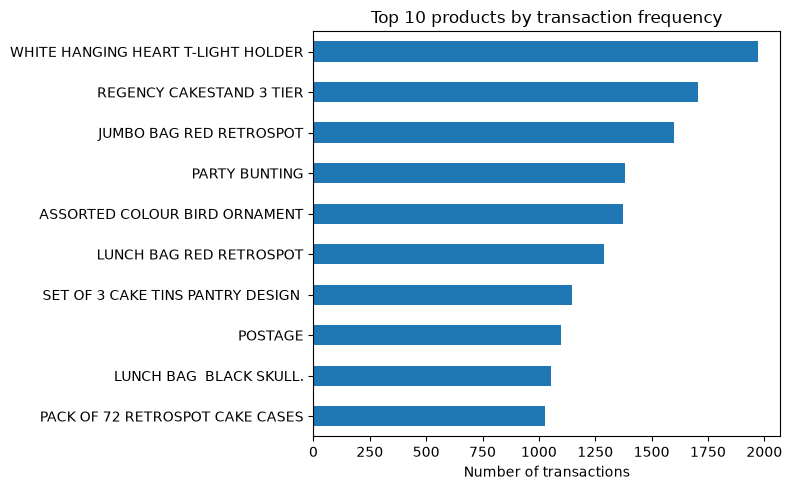

In [25]:

# ---------------------------------------------------------------
# Step 7: Visualize top-selling products
# ---------------------------------------------------------------
top_products = (
    pd.Series(item_counts)
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

top_products.plot.barh(title="Top 10 products by transaction frequency", figsize=(8, 5))
plt.xlabel("Number of transactions")
plt.tight_layout()
plt.show()